# Exploratory Data Analysis of the Data Center Load Dataset

This notebook explores power usage, efficiency, and utilization in an enterprise data center dataset. The goal is to understand:
- how power demand changes over time,
- what drives cooling load and PUE,
- whether temperature or compute utilization are strong predictors,
- and how extreme facility load events behave.

The analysis uses time-series inspection, summary statistics, correlation analysis, seasonal and hourly patterns, and extreme-event comparison.

### Data overview

- Import standard libraries for data analysis and visualization.
- Read the Excel file from the data folder and parse the main sheet.
- Convert Timestamp to datetime so time-based analysis works correctly.
- Show the first rows to confirm the dataset structure and column names.
- Inspect the data dimensions and data types.
- Check for missing values and see which columns have the most nulls.

In [33]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

path = Path("data") / "Enterprise_DC_Load_Dataset_2024 500 CPU 100GPU System.xlsx"

df = pd.read_excel(path, sheet_name="Full_Dataset", header=1)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df.head()

,Timestamp,Month,Day,Hour,T_amb (°C),u_CPU fleet,u_GPU fleet,P_CPU fleet (kW),Q_CPU fleet (kVAr),P_CPU/server (W),...,Q_lighting (kVAr),P_BMS/sec (kW),Q_BMS/sec (kVAr),P_facility (kW),Q_facility (kVAr),S_facility (kVA),PF_facility,PUE,R_rack composite,ML Split
0,2024-01-01 00:00:00,1,Monday,0,-1.22,0.1959,0.1520,97.213,41.412,194.43,...,7.26,8,4.32,248.428,120.326,276.034,0.9000,1.5494,0.3379,Train
1,2024-01-01 01:00:00,1,Monday,1,3.32,0.2512,0.2169,107.720,45.888,215.44,...,7.26,8,4.32,282.096,137.028,313.616,0.8995,1.5428,0.3862,Train
2,2024-01-01 02:00:00,1,Monday,2,-0.12,0.2562,0.2454,108.676,46.296,217.35,...,7.26,8,4.32,289.313,140.463,321.608,0.8996,1.5302,0.4001,Train
3,2024-01-01 03:00:00,1,Monday,3,1.82,0.5654,0.2885,167.429,71.325,334.86,...,7.26,8,4.32,384.500,185.502,426.909,0.9007,1.5031,0.5357,Train
4,2024-01-01 04:00:00,1,Monday,4,0.62,0.4087,0.6201,137.649,58.638,275.30,...,7.26,8,4.32,428.274,209.387,476.720,0.8984,1.4903,0.6156,Train


In [34]:
df.shape
df.info()
df.isna().sum().sort_values(ascending=False).head(10)

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 53 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Timestamp              8760 non-null   datetime64[us]
 1   Month                  8760 non-null   int64         
 2   Day                    8760 non-null   str           
 3   Hour                   8760 non-null   int64         
 4   T_amb (°C)             8760 non-null   float64       
 5   u_CPU fleet            8760 non-null   float64       
 6   u_GPU fleet            8760 non-null   float64       
 7   P_CPU fleet (kW)       8760 non-null   float64       
 8   Q_CPU fleet (kVAr)     8760 non-null   float64       
 9   P_CPU/server (W)       8760 non-null   float64       
 10  Q_CPU/server (VAr)     8760 non-null   float64       
 11  P_GPU fleet (kW)       8760 non-null   float64       
 12  Q_GPU fleet (kVAr)     8760 non-null   float64       
 13  P_GPU/server (

Timestamp              0
P_PSU loss (kW)        0
P_PDU loss (kW)        0
Q_PDU loss (kVAr)      0
P_UPS loss (kW)        0
Q_UPS loss (kVAr)      0
P_XFMR loss (kW)       0
Q_XFMR loss (kVAr)     0
P_cable loss (kW)      0
Q_cable loss (kVAr)    0
dtype: int64

In [35]:
key_cols = [
    "P_IT total (kW)",
    "P_facility (kW)",
    "P_cooling (kW)",
    "P_loss total (kW)",
    "PUE",
    "T_amb (°C)",
    "u_CPU fleet",
    "u_GPU fleet",
]

df[key_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
P_IT total (kW),8760.0,265.100240,85.012748,132.7500,188.128000,258.42200,334.08125,466.2000
P_facility (kW),8760.0,409.142861,125.656788,208.9010,296.527500,398.11950,509.11150,723.3260
P_cooling (kW),8760.0,77.324111,28.126861,31.2580,54.040000,73.05650,96.14650,161.7640
P_loss total (kW),8760.0,43.718512,14.019716,21.8920,31.024500,42.61700,55.09425,76.8830
PUE,8760.0,1.551901,0.046730,1.4515,1.515200,1.55110,1.58270,1.6985
T_amb (°C),8760.0,15.009111,10.916383,-5.0000,4.710000,15.06000,25.41000,38.2400
u_CPU fleet,8760.0,0.487058,0.246573,0.1500,0.258975,0.46865,0.68950,0.9800
u_GPU fleet,8760.0,0.419238,0.223135,0.0500,0.233000,0.40555,0.59110,1.0000


In [36]:
df["Month"] = df["Timestamp"].dt.month
df["DayOfWeek"] = df["Timestamp"].dt.day_name()
df["Hour"] = df["Timestamp"].dt.hour
df["IsWeekend"] = df["DayOfWeek"].isin(["Saturday", "Sunday"])

In [37]:
print("Duplicate rows:", df.duplicated().sum())

invalid_power = df[
    (df["P_IT total (kW)"] < 0)
    | (df["P_facility (kW)"] < 0)
    | (df["P_cooling (kW)"] < 0)
]
print("Invalid power rows:", invalid_power.shape[0])
print(invalid_power.head())

invalid_util = df[
    (df["u_CPU fleet"] < 0)
    | (df["u_CPU fleet"] > 100)
    | (df["u_GPU fleet"] < 0)
    | (df["u_GPU fleet"] > 100)
]
print("Invalid utilization rows:", invalid_util.shape[0])
print(invalid_util.head())

Duplicate rows: 0
Invalid power rows: 0
Empty DataFrame
Columns: [Timestamp, Month, Day, Hour, T_amb (°C), u_CPU fleet, u_GPU fleet, P_CPU fleet (kW), Q_CPU fleet (kVAr), P_CPU/server (W), Q_CPU/server (VAr), P_GPU fleet (kW), Q_GPU fleet (kVAr), P_GPU/server (W), Q_GPU/server (VAr), P_IT total (kW), Q_IT total (kVAr), PF_IT, P_rack CPU avg (kW), Q_rack CPU avg (kVAr), R_rack CPU, P_rack GPU avg (kW), Q_rack GPU avg (kVAr), R_rack GPU, P_PDU avg (kW), Q_PDU avg (kVAr), R_PDU, P_PSU loss (kW), Q_PSU loss (kVAr), P_PDU loss (kW), Q_PDU loss (kVAr), P_UPS loss (kW), Q_UPS loss (kVAr), P_XFMR loss (kW), Q_XFMR loss (kVAr), P_cable loss (kW), Q_cable loss (kVAr), P_loss total (kW), Q_loss total (kVAr), COP, P_cooling (kW), Q_cooling (kVAr), P_lighting (kW), Q_lighting (kVAr), P_BMS/sec (kW), Q_BMS/sec (kVAr), P_facility (kW), Q_facility (kVAr), S_facility (kVA), PF_facility, PUE, R_rack composite, ML Split, DayOfWeek, IsWeekend]
Index: []

[0 rows x 55 columns]
Invalid utilization rows: 0
E

- The system has 8,760 hourly records and all key variables are complete.
- Average facility power is about 409 kW, while IT load is about 265 kW. Cooling adds about 77 kW on average and losses about 44 kW.
- Average PUE is 1.55, which is good, but it can rise to 1.70 during hotter or heavier load periods.
- Ambient temperature ranges widely, from moderate to very hot, so temperature likely has a strong effect on cooling demand.
- CPU and GPU utilization averages are below 50%, which means the data center often has room for additional compute.

Because PUE also has a moderate spread, I expect the next step should focus on how temperature and utilization drive PUE.

### Correlation between key variables
What has an influence on PUE?

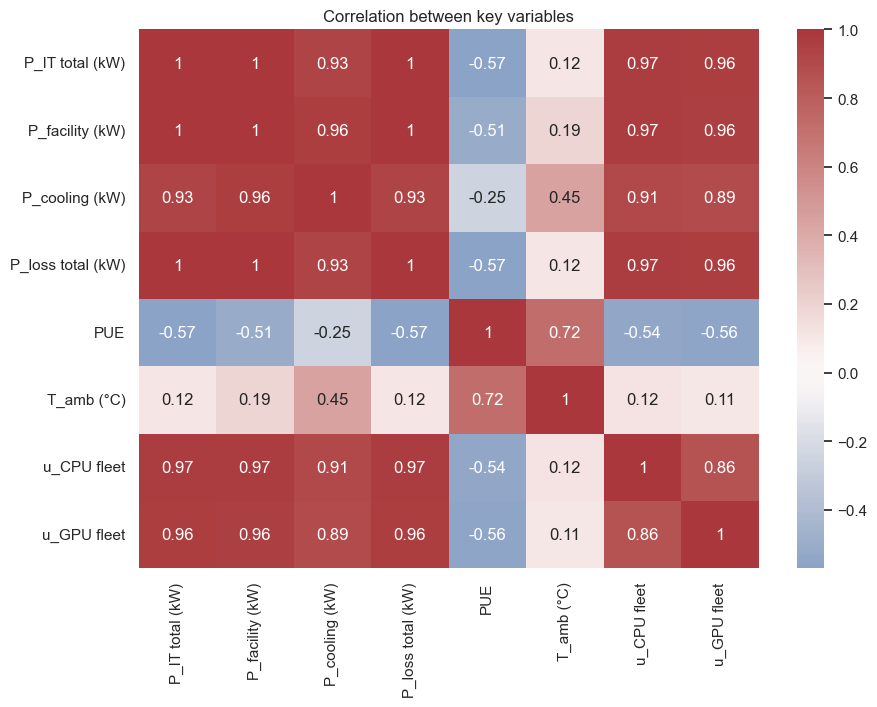

In [38]:
corr = df[key_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="vlag", center=0)
plt.title("Correlation between key variables")
plt.show()

In this heatmap, the important part is to analyse the correlation between PUE and other variables. For instance, we can see that there is a strong correlation between PUE and T_amb(°C) that we will need to explore. However, a lower correlation with CPU and GPU would mean utilization is not the main factor influencing PUE. 

### When is the power load highest?

#### Analysing the 10 highest facility power usage events and the conditions at those times

In [39]:
df.nlargest(10, "P_facility (kW)")[
    ["Timestamp", "P_facility (kW)", "P_IT total (kW)", "P_cooling (kW)", "PUE", "T_amb (°C)", "u_CPU fleet", "u_GPU fleet"]
]

,Timestamp,P_facility (kW),P_IT total (kW),P_cooling (kW),PUE,T_amb (°C),u_CPU fleet,u_GPU fleet
5099,2024-07-31 11:00:00,723.326,466.200,157.244,1.5515,28.38,0.9800,1.0000
4136,2024-06-21 08:00:00,719.322,460.828,159.497,1.5609,30.27,0.9800,0.9710
4255,2024-06-26 07:00:00,718.046,461.253,157.727,1.5567,29.39,0.9619,0.9918
3297,2024-05-17 09:00:00,717.836,458.514,160.708,1.5656,31.17,0.9499,0.9894
3107,2024-05-09 11:00:00,715.505,460.686,155.847,1.5531,28.60,0.9800,0.9702
4712,2024-07-15 08:00:00,713.348,458.153,156.640,1.5570,29.38,0.9376,1.0000
3564,2024-05-28 12:00:00,713.075,458.781,155.635,1.5543,28.81,0.9648,0.9755
3968,2024-06-14 08:00:00,711.098,456.257,156.598,1.5585,29.66,0.9486,0.9785
5266,2024-08-07 10:00:00,711.097,458.861,153.564,1.5497,27.80,0.9800,0.9603
4208,2024-06-24 08:00:00,711.003,458.508,153.881,1.5507,28.01,0.9395,1.0000


The highest facility load events generally occur when IT power (CPU, GPU, ...) and ambient temperature are both high. This means the data center experiences its biggest energy stress during hot, busy periods.

#### Average monthly power plot to compare seasonal change. 

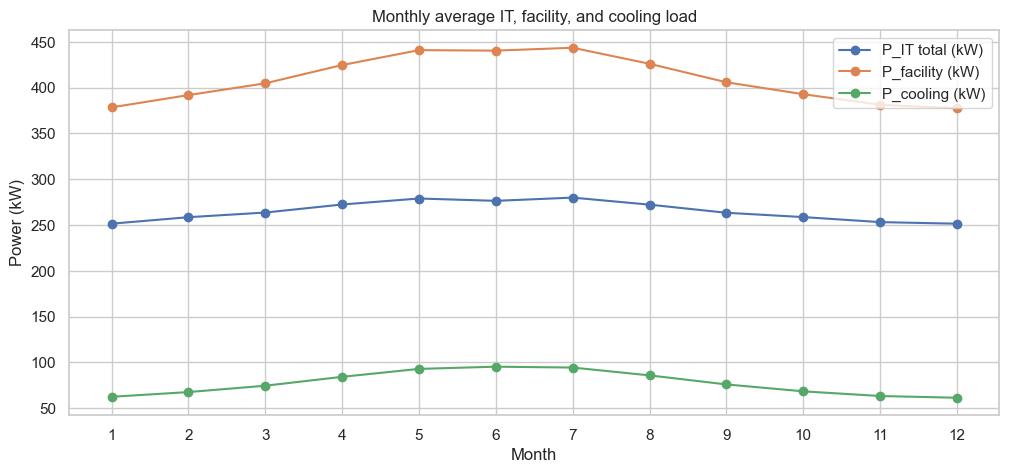

In [40]:
monthly = df.groupby("Month")[
    ["P_IT total (kW)", "P_facility (kW)", "P_cooling (kW)", "PUE", "T_amb (°C)"]
].mean()

monthly[["P_IT total (kW)", "P_facility (kW)", "P_cooling (kW)"]].plot(
    marker="o", figsize=(12, 5)
)
plt.title("Monthly average IT, facility, and cooling load")
plt.xlabel("Month")
plt.ylabel("Power (kW)")
plt.xticks(range(1, 13))
plt.show()

- The IT Load is relatively stable month to month (from an average 250kW to an average 275kW meaning that the IT Load only increased about 10% ).
- Cooling raised a lot more (by about 40% in average). 
- This indicates that cooling rather than IT activity drives much of the monthly variation in facility load.

 #### Average hourly power plot to compare load distribution throughout the day

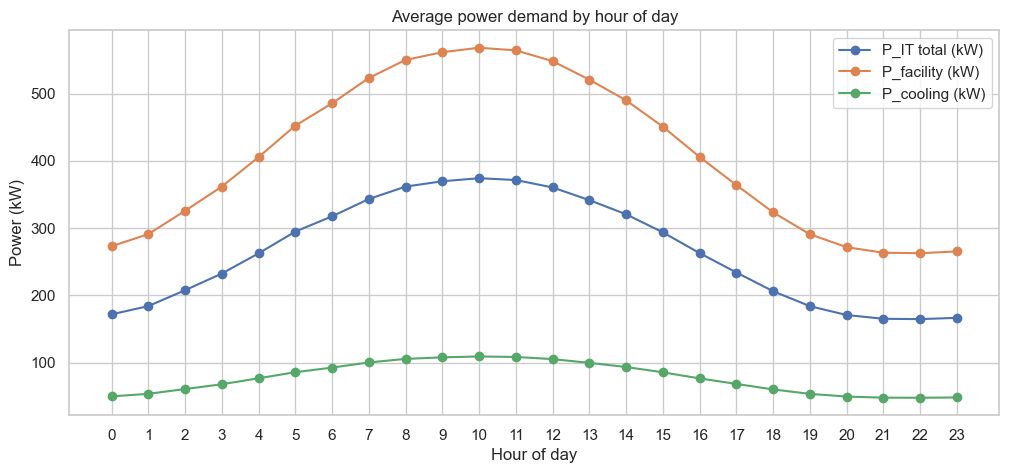

In [41]:
hourly = df.groupby("Hour")[
    ["P_IT total (kW)", "P_facility (kW)", "P_cooling (kW)"]
].mean()

hourly.plot(marker="o", figsize=(12, 5))
plt.title("Average power demand by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Power (kW)")
plt.xticks(range(0, 24))
plt.show()

The hourly average profile shows a strong daily cycle. Facility power climbs from a low of about 273 kW around midnight to a peak of roughly 568 kW in the late morning, then falls back toward 265 kW by late evening. Cooling load follows the same pattern, rising from about 50 kW overnight to around 109 kW at peak. This means the data center is busiest and least efficient during daytime hours, and the most important opportunities for energy savings are in the morning and early afternoon periods.

#### Day-of-week facility power distribution

/var/folders/rm/k6mp0xgs0mg3cc2tp2psly6h0000gp/T/ipykernel_43097/580346788.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


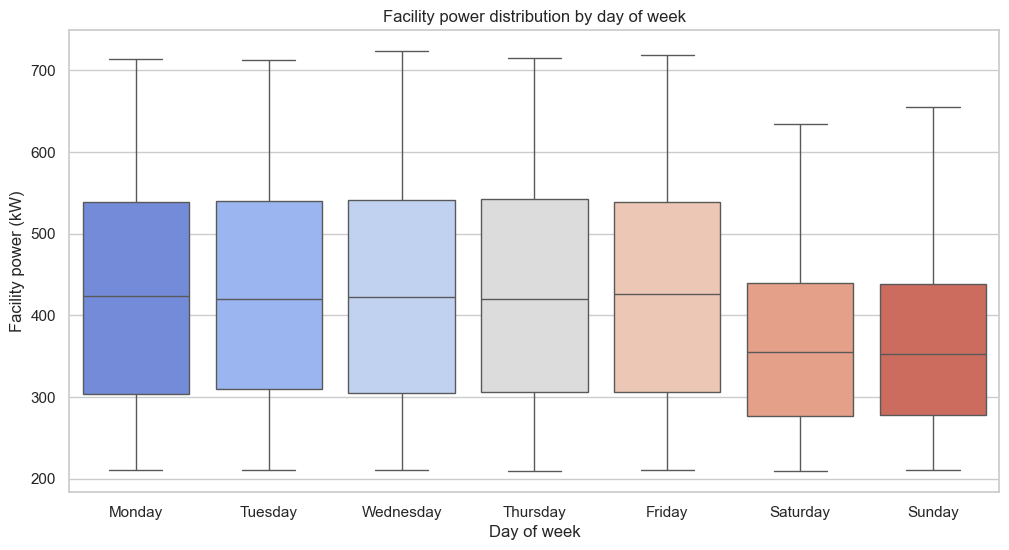

In [42]:
plt.figure(figsize=(12, 6))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(
    x="DayOfWeek",
    y="P_facility (kW)",
    data=df,
    order=order,
    palette="coolwarm"
)
plt.title("Facility power distribution by day of week")
plt.xlabel("Day of week")
plt.ylabel("Facility power (kW)")
plt.show()

The day-of-week distribution shows a strong weekly effect. Weekdays are consistently higher, with average facility power around 427–429 kW, while weekends drop by about 15%. Weekday variability is also larger, and the highest facility power readings occur on business days. This indicates that the data center is busier during the normal workweek, while weekends are calmer but still maintain a steady baseline load. Because the minimums are similar every day, the weekend drop comes from reduced peak and mid-range load rather than a lower baseline.

The weekday means are nearly identical, so there is no single “worst” weekday; the facility load is stable across Monday through Friday.

If the goal is to reduce peak demand, the best opportunities are during weekday business hours rather than weekend baseline load

### Understanding Ambiant Temperature and Utilization Effects

#### Cooling load vs ambient temperature

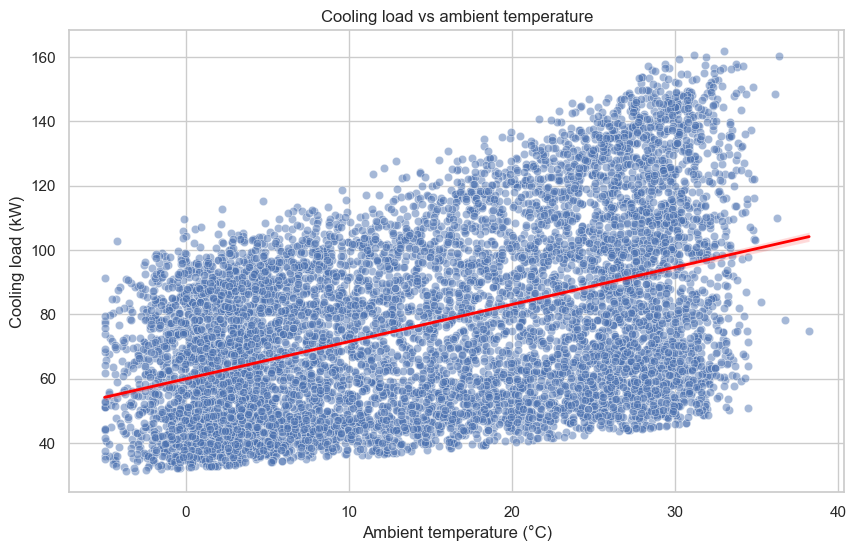

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="T_amb (°C)",
    y="P_cooling (kW)",
    data=df,
    alpha=0.5
)
sns.regplot(
    x="T_amb (°C)",
    y="P_cooling (kW)",
    data=df,
    scatter=False,
    color="red",
    line_kws={"linewidth": 2}
)
plt.title("Cooling load vs ambient temperature")
plt.xlabel("Ambient temperature (°C)")
plt.ylabel("Cooling load (kW)")
plt.show()

The relationship is real and positive, but not perfect.
Correlation is about 0.45 (was found earlier), meaning higher temperature tends to increase cooling load.
The linear slope is about 1.16 kW of cooling per 1°C rise which means every degree warmer adds roughly 1.2 kW of cooling demand, so ambient temperature is a meaningful driver of cooling energy.

Therefore:
- cooling is variable and weather-dependent
- This confirms that the heat management system is working harder when it gets hotter, which is expected for a data center.

#### PUE vs ambient temperature

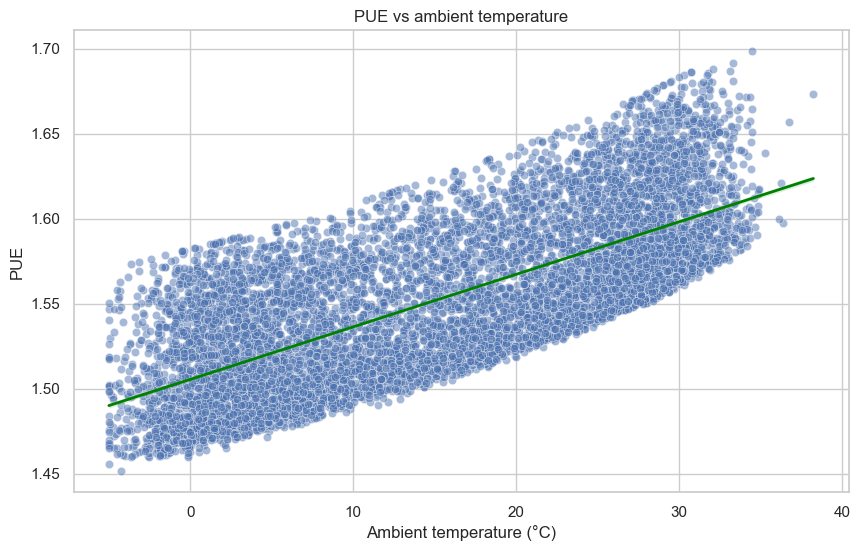

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="T_amb (°C)",
    y="PUE",
    data=df,
    alpha=0.5
)
sns.regplot(
    x="T_amb (°C)",
    y="PUE",
    data=df,
    scatter=False,
    color="green",
    line_kws={"linewidth": 2}
)
plt.title("PUE vs ambient temperature")
plt.xlabel("Ambient temperature (°C)")
plt.ylabel("PUE")
plt.show()

PUE has a stronger relationship with temperature: correlation is 0.721. The slope is about 0.0031 PUE per 1°C. That means a 10°C increase is associated with roughly a 0.03 increase in PUE. 

According to The Green Grid modern hyperscale data centers typically achieve annual PUE values between 1.1 and 1.3, while older facilities often have PUE values above 1.5. This means that a 0.03 increase per 10°C is to be considered. Especially since the PUE is already high at low ambient temperatures.


Ambient temperature is a strong predictor of efficiency.
As outside air warms, PUE worsens, which usually means more facility power is needed for the same IT output.

#### PUE vs CPU and GPU utilization

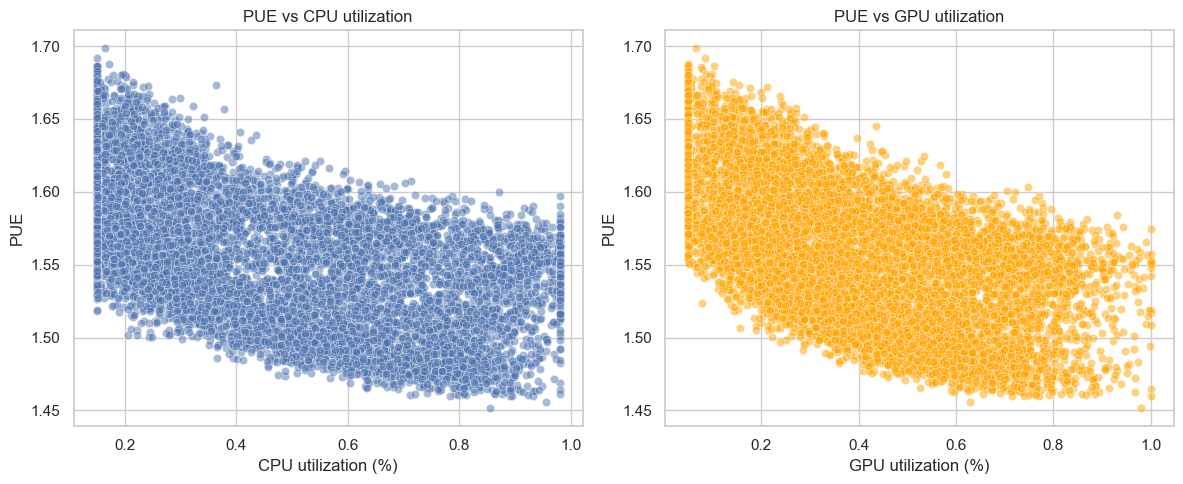

In [45]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x="u_CPU fleet",
    y="PUE",
    data=df,
    alpha=0.5
)
plt.title("PUE vs CPU utilization")
plt.xlabel("CPU utilization (%)")
plt.ylabel("PUE")

plt.subplot(1, 2, 2)
sns.scatterplot(
    x="u_GPU fleet",
    y="PUE",
    data=df,
    alpha=0.5,
    color="orange"
)
plt.title("PUE vs GPU utilization")
plt.xlabel("GPU utilization (%)")
plt.ylabel("PUE")

plt.tight_layout()
plt.show()

Both CPU and GPU utilization correlate negatively with PUE. Slopes are around -0.10 PUE per unit utilization. That means higher utilization tends to improve efficiency.


Therefore when the data center is busier, it generally uses power more efficiently. This happens because the IT load denominator grows faster than facility overhead, reducing PUE. So even though temperature raises PUE, utilization pulls it down when compute load increases.


This is a key insight:
- Higher temperature makes efficiency worse,
- but higher utilization makes efficiency better.
- The net PUE depends on the balance between those two effects.

#### Heatmap of PUE by day and hour

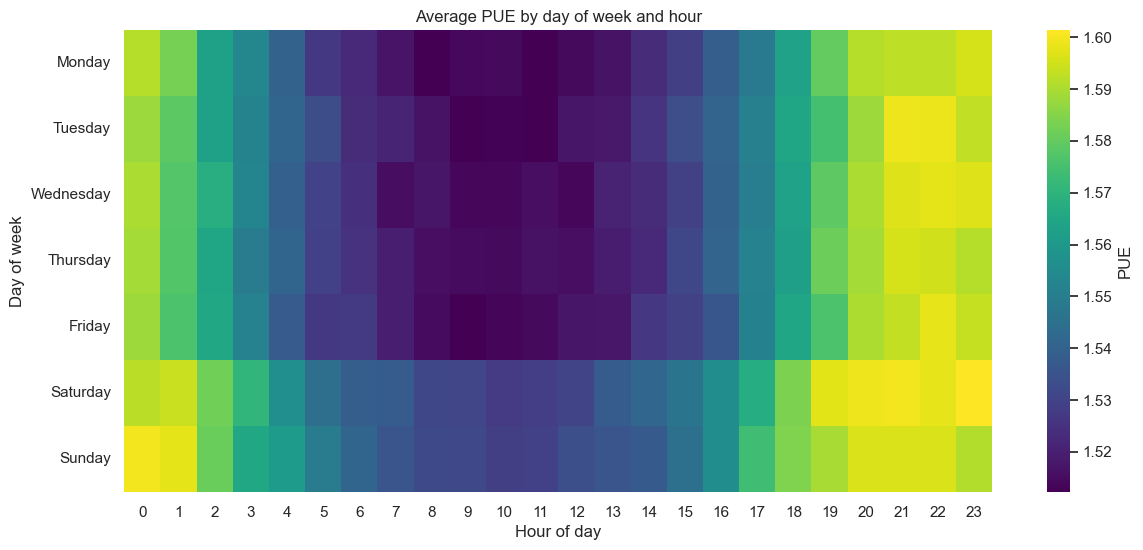

In [46]:
pue_pivot = df.pivot_table(
    index="DayOfWeek",
    columns="Hour",
    values="PUE",
    aggfunc="mean"
).reindex(order)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pue_pivot,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "PUE"}
)
plt.title("Average PUE by day of week and hour")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.show()

The heatmap aggregates average PUE by weekday and hour. Peak average PUE occurs at Saturday 23:00 with about 1.601.


- The highest average inefficiency is not during weekday peak hours, but late on Saturday.
- That suggests weekend/late-night operation has a poor IT-to-facility ratio: facility power is still consumed, but IT load is lower.
- In other words, low IT activity combined with baseline cooling/losses can raise PUE.

This is an important operational insight:
The worst efficiency periods can occur outside business hours, especially when the facility is still running but compute load drops.

## Conclusion

The dataset shows that the data center’s power profile is driven by both IT demand and ambient temperature. Cooling power is strongly temperature-dependent, and PUE tends to worsen as outside temperature rises. Daily and weekly patterns are visible through the hourly and weekday analyses, although the data center appears to run fairly consistently across the day. The highest facility power events coincide with hot weather and increased cooling demand, which suggests that improving cooling efficiency in warm periods would have the biggest impact on overall energy performance.

Key takeaways:
- Cooling is a major contributor to facility power and varies seasonally.
- Temperature has a stronger influence on PUE than CPU/GPU utilization.
- Extreme load periods are characterized by high ambient temperature and high cooling share.
- Understanding these patterns can help target efficiency improvements in thermal management and load balancing.

## Part 2 — Toward Load Disaggregation: Components, Predictors, and Conditioning Variables

Part 1 treated the data center as a single facility signal. The goal now is to prepare for **disaggregating the total facility load into its physical sub-components**, and to identify candidate **conditioning variables** for a conditional diffusion model — the same style of approach used previously for PV disaggregation (conditioned on net consumption + GHI) and heat pump disaggregation (conditioned on HDH).

This part covers:
1. Defining the load components that make up `P_facility (kW)` and verifying they reconstruct it exactly.
2. Visualizing how the composition changes over time.
3. Looking at each component's distribution, both on its own and conditioned on candidate drivers.
4. Engineering candidate predictor/conditioning variables (cyclical time encoding, degree-hours, workload proxies).
5. Quantifying which predictors relate to which component.
6. A key finding about how deterministic this particular dataset is, and what that means for the diffusion modeling approach.
7. Checking the built-in train/validation/test split.
8. A summary table of proposed conditioning variables per component, and a research roadmap for next steps.

### 2.1 Defining the load hierarchy

`P_facility (kW)` is fully observed and already decomposes exactly into five physical sub-loads:

```
P_facility = P_CPU_fleet + P_GPU_fleet + P_cooling + P_loss_total + P_fixed
```

where `P_fixed = P_lighting + P_BMS/sec` (both constant). This means disaggregation here is **not** a blind-source-separation problem — the ground-truth components already exist as columns, which lets us validate a disaggregation model directly instead of only training on a proxy. The five disaggregation targets we'll use (per the CPU/GPU + Cooling + Losses + Fixed split) are:

- **IT – CPU**: `P_CPU fleet (kW)`
- **IT – GPU**: `P_GPU fleet (kW)`
- **Cooling**: `P_cooling (kW)`
- **Losses**: `P_loss total (kW)` (PSU + PDU + UPS + transformer + cable)
- **Fixed**: `P_lighting (kW) + P_BMS/sec (kW)`

Note: the 2024 file doesn't break IT load down further than CPU vs. GPU fleets (no memory/storage/NIC split — that finer breakdown exists only in the companion 2026 file, which isn't present in this repo). We flag this as a data gap for future work in the roadmap at the end.

In [47]:
df["P_fixed (kW)"] = df["P_lighting (kW)"] + df["P_BMS/sec (kW)"]

targets = ["P_CPU fleet (kW)", "P_GPU fleet (kW)", "P_cooling (kW)", "P_loss total (kW)", "P_fixed (kW)"]
target_labels = {
    "P_CPU fleet (kW)": "IT - CPU",
    "P_GPU fleet (kW)": "IT - GPU",
    "P_cooling (kW)": "Cooling",
    "P_loss total (kW)": "Losses",
    "P_fixed (kW)": "Fixed",
}

reconstructed = df[targets].sum(axis=1)
recon_error = (df["P_facility (kW)"] - reconstructed).abs()

print("Reconstruction check: P_facility vs sum of the 5 components")
print("  max error (kW):", recon_error.max())
print("  mean error (kW):", recon_error.mean())
print("\nP_fixed unique values (kW):", df["P_fixed (kW)"].unique())
print("\nShare of P_facility by component (annual average):")
print((df[targets].mean() / df["P_facility (kW)"].mean()).rename(index=target_labels).round(3))

Reconstruction check: P_facility vs sum of the 5 components
  max error (kW): 0.002000000000066393
  mean error (kW): 0.0003913242009259017

P_fixed unique values (kW): [23]

Share of P_facility by component (annual average):
IT - CPU    0.373
IT - GPU    0.275
Cooling     0.189
Losses      0.107
Fixed       0.056
dtype: float64


### 2.2 Visualizing the composition over time

First a daily-average stacked area for the full year (to see seasonal composition shifts), then a zoom on one representative week to see the diurnal composition pattern.

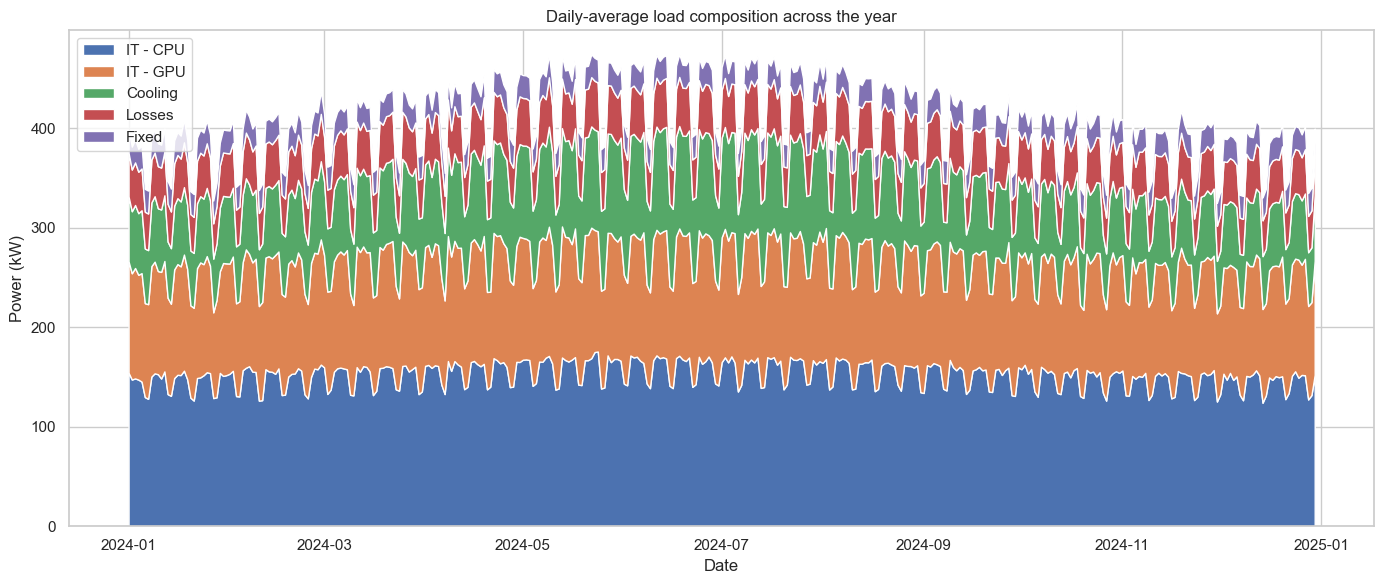

In [48]:
daily = df.set_index("Timestamp")[targets].resample("D").mean()

plt.figure(figsize=(14, 6))
plt.stackplot(
    daily.index,
    [daily[c] for c in targets],
    labels=[target_labels[c] for c in targets],
)
plt.legend(loc="upper left")
plt.title("Daily-average load composition across the year")
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.tight_layout()
plt.show()

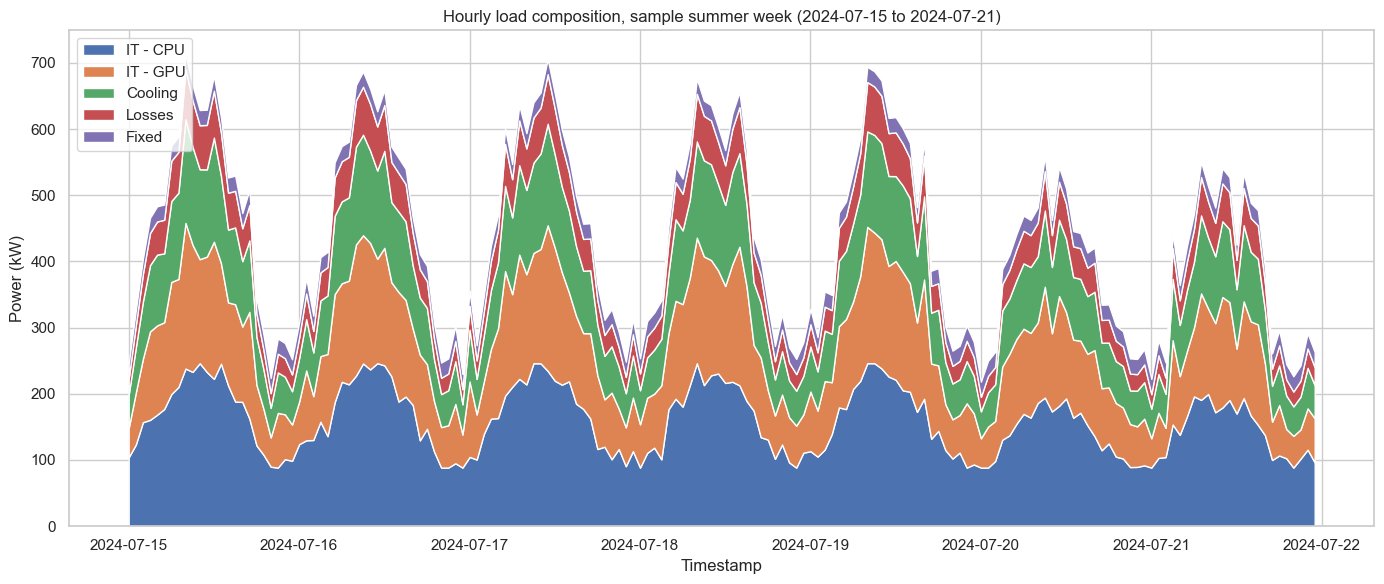

In [49]:
week = df[(df["Timestamp"] >= "2024-07-15") & (df["Timestamp"] < "2024-07-22")].set_index("Timestamp")

plt.figure(figsize=(14, 6))
plt.stackplot(
    week.index,
    [week[c] for c in targets],
    labels=[target_labels[c] for c in targets],
)
plt.legend(loc="upper left")
plt.title("Hourly load composition, sample summer week (2024-07-15 to 2024-07-21)")
plt.xlabel("Timestamp")
plt.ylabel("Power (kW)")
plt.tight_layout()
plt.show()

### 2.3 Marginal distribution of each component

Before picking conditioning variables, it helps to see each target's unconditional distribution — this is what a diffusion model would have to match if given no conditioning at all.

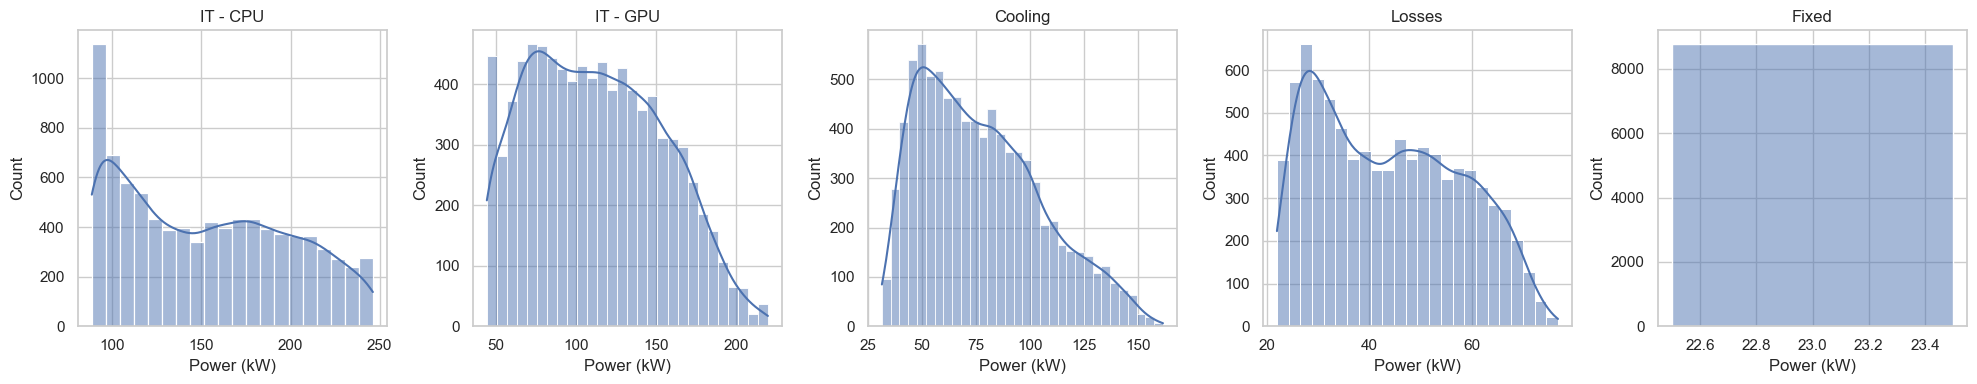

In [50]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, targets):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(target_labels[col])
    ax.set_xlabel("Power (kW)")
plt.tight_layout()
plt.show()

### 2.4 Do candidate conditions collapse the spread?

A good conditioning variable should sharply reduce the spread (and any multimodality) of a component's distribution once we condition on it. We check two candidates suggested by Part 1's findings: **ambient temperature** for cooling load, and **hour of day** for IT load.

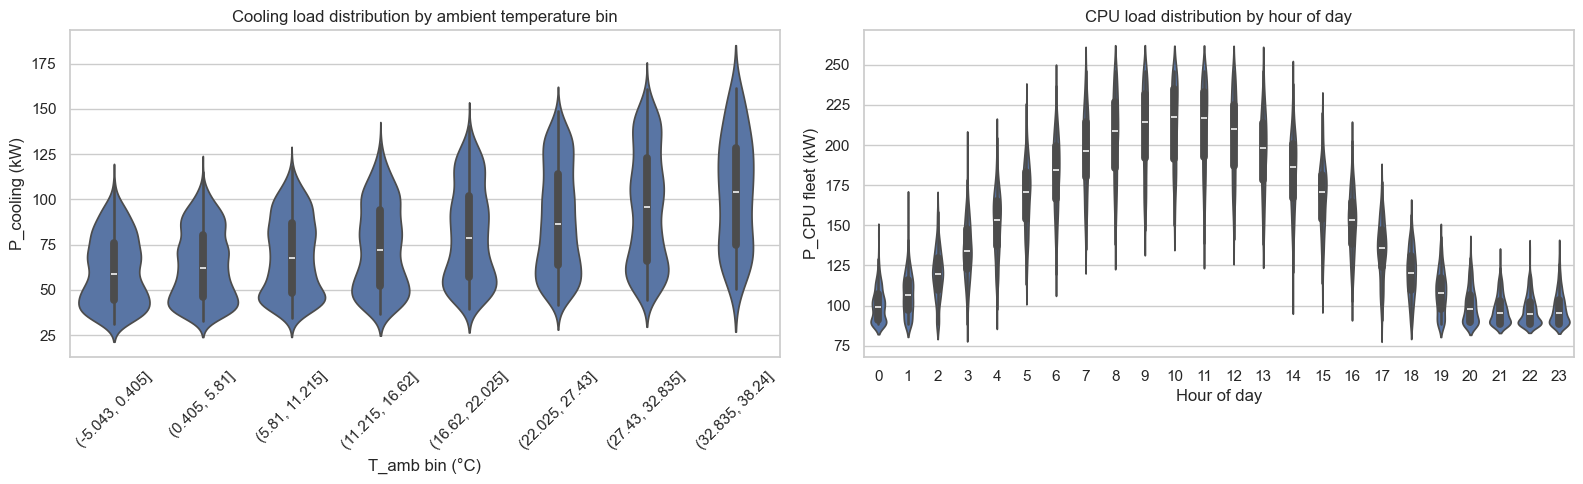

In [51]:
df["T_amb_bin"] = pd.cut(df["T_amb (°C)"], bins=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.violinplot(x="T_amb_bin", y="P_cooling (kW)", data=df, ax=axes[0])
axes[0].set_title("Cooling load distribution by ambient temperature bin")
axes[0].set_xlabel("T_amb bin (°C)")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(x="Hour", y="P_CPU fleet (kW)", data=df, ax=axes[1])
axes[1].set_title("CPU load distribution by hour of day")
axes[1].set_xlabel("Hour of day")

plt.tight_layout()
plt.show()

### 2.5 Candidate predictor / conditioning variable engineering

We add:
- **Cyclical time encoding** (`hour_sin/cos`, `month_sin/cos`) — raw `Hour` correlates weakly with utilization (~-0.25) because the daily cycle isn't monotonic, but the cyclical encoding captures it much better (see check below).
- **Degree-hours** from `T_amb (°C)`, using a data-center base temperature of 20°C (`CDH` = cooling degree-hours, `HDH` = heating degree-hours). Since each row is already one hour, degree-hours here equal the instantaneous degree deviation.
- **Workload proxy**: `u_CPU fleet * u_GPU fleet` as a combined utilization intensity term.

We deliberately **exclude** several columns that looked promising but turn out to be redundant re-expressions of variables we already have (verified numerically): `R_rack CPU`/`R_rack GPU` are within noise of `u_CPU fleet`/`u_GPU fleet` (corr > 0.99999), and `P_CPU/server`, `P_rack CPU avg`, etc. are exact linear rescalings of the fleet totals. Including both would just duplicate a predictor under a different name.

In [52]:
import numpy as np

BASE_TEMP_C = 20.0  # data-center degree-hour base temperature (ASHRAE-style default)

hour_rad = 2 * np.pi * df["Hour"] / 24
df["hour_sin"] = np.sin(hour_rad)
df["hour_cos"] = np.cos(hour_rad)

month_rad = 2 * np.pi * (df["Month"] - 1) / 12
df["month_sin"] = np.sin(month_rad)
df["month_cos"] = np.cos(month_rad)

df["CDH"] = (df["T_amb (°C)"] - BASE_TEMP_C).clip(lower=0)
df["HDH"] = (BASE_TEMP_C - df["T_amb (°C)"]).clip(lower=0)

df["workload_intensity"] = df["u_CPU fleet"] * df["u_GPU fleet"]

print("corr(u_CPU fleet, Hour)     :", df["u_CPU fleet"].corr(df["Hour"]).round(3))
print("corr(u_CPU fleet, hour_cos) :", df["u_CPU fleet"].corr(df["hour_cos"]).round(3))
print("corr(u_CPU fleet, hour_sin) :", df["u_CPU fleet"].corr(df["hour_sin"]).round(3))

corr(u_CPU fleet, Hour)     : -0.252
corr(u_CPU fleet, hour_cos) : -0.789
corr(u_CPU fleet, hour_sin) : 0.452


### 2.6 Which predictors relate to which component?

We now correlate every candidate predictor against every target component, using both Pearson (linear) and Spearman (monotonic/rank) correlation, since some of the underlying relationships turn out to be nonlinear.

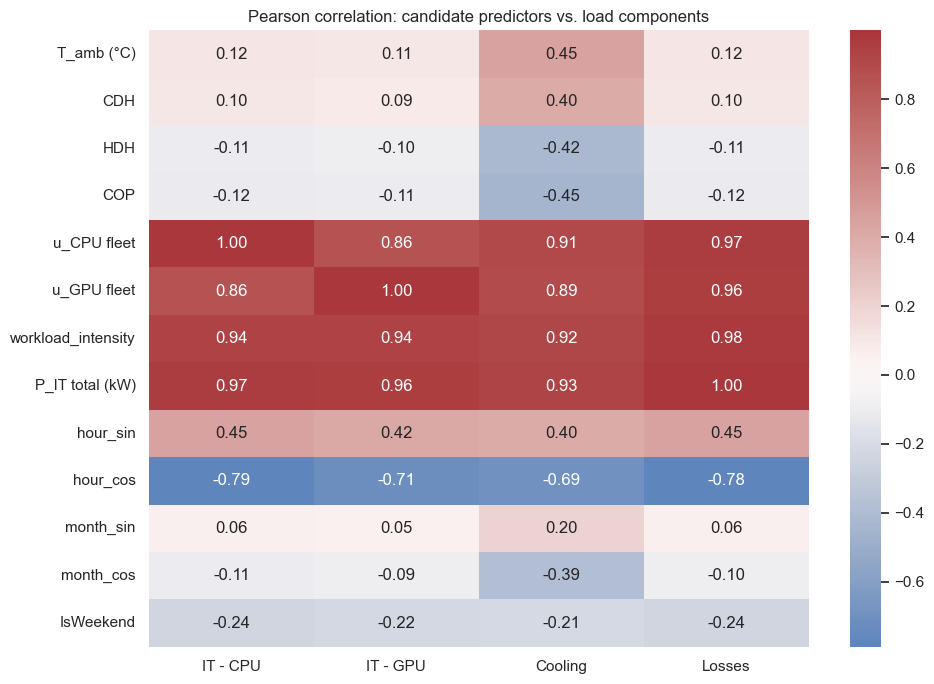

In [53]:
targets.remove("P_fixed (kW)")
target_labels.pop("P_fixed (kW)")

candidate_predictors = [
    "T_amb (°C)", "CDH", "HDH", "COP",
    "u_CPU fleet", "u_GPU fleet", "workload_intensity",
    "P_IT total (kW)",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "IsWeekend",
]

pearson_corr = pd.DataFrame(
    {t: df[candidate_predictors].corrwith(df[t]) for t in targets}
).rename(columns=target_labels)

spearman_corr = pd.DataFrame(
    {t: df[candidate_predictors].corrwith(df[t], method="spearman") for t in targets}
).rename(columns=target_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Pearson correlation: candidate predictors vs. load components")
plt.tight_layout()
plt.show()

In [55]:
print("Spearman correlation: candidate predictors vs. load components\n")
print(spearman_corr.round(3))

# "Fixed" is a literal constant (23 kW), so correlation against it is undefined (NaN) -
# exclude it from the top-predictor summary rather than treat that as a real gap.
print("\nTop predictor per component (by |Pearson r|), excluding the constant 'Fixed' component:")
print(corr_for_ranking.abs().idxmax().to_frame("top_predictor").join(
    corr_for_ranking.abs().max().rename("abs_corr")
))

Spearman correlation: candidate predictors vs. load components

                    IT - CPU  IT - GPU  Cooling  Losses
T_amb (°C)             0.107     0.096    0.419   0.105
CDH                    0.101     0.087    0.379   0.097
HDH                   -0.104    -0.092   -0.408  -0.102
COP                   -0.107    -0.096   -0.419  -0.105
u_CPU fleet            1.000     0.859    0.911   0.964
u_GPU fleet            0.859     1.000    0.905   0.962
workload_intensity     0.958     0.967    0.941   0.999
P_IT total (kW)        0.964     0.962    0.942   1.000
hour_sin               0.496     0.461    0.455   0.496
hour_cos              -0.764    -0.697   -0.693  -0.758
month_sin              0.063     0.057    0.224   0.062
month_cos             -0.089    -0.082   -0.341  -0.088
IsWeekend             -0.228    -0.212   -0.194  -0.228

Top predictor per component (by |Pearson r|), excluding the constant 'Fixed' component:
            top_predictor  abs_corr
IT - CPU      u_CPU fleet  

### 2.7 Key finding: this dataset's components are (almost) deterministic functions of a few variables

The correlations above are extremely high for some pairs — high enough to check whether the underlying relationship is actually an exact formula rather than a statistical association. Since this dataset is explicitly described as **physics-based** (built from manufacturer power curves and standard electrical engineering parameters, not measured/metered data), that's worth verifying directly.

In [56]:
# 1) CPU/GPU fleet power vs. utilization: linear idle+dynamic server power model
pred_cpu = 500 * (0.120 + (0.500 - 0.120) * df["u_CPU fleet"])   # 500 servers, 120W idle / 500W peak
pred_gpu = 100 * (0.350 + (2.200 - 0.350) * df["u_GPU fleet"])   # 100 servers, 350W idle / 2200W peak
print("P_CPU fleet residual std (kW):", (df['P_CPU fleet (kW)'] - pred_cpu).std().round(4))
print("P_GPU fleet residual std (kW):", (df['P_GPU fleet (kW)'] - pred_gpu).std().round(4))

# 2) COP as a linear function of ambient temperature
cop_fit = np.polyfit(df["T_amb (°C)"], df["COP"], 1)
print("\nCOP ≈ {:.4f} * T_amb + {:.4f}  (residual std: {:.5f})".format(
    cop_fit[0], cop_fit[1], (df["COP"] - np.polyval(cop_fit, df["T_amb (°C)"])).std()
))

# 3) Cooling load as IT heat rejected through the COP
pred_cooling = df["P_IT total (kW)"] / df["COP"]
print("\nP_cooling residual std vs. P_IT_total / COP (kW):", (df["P_cooling (kW)"] - pred_cooling).std().round(4))

# 4) Losses as a fixed fraction of IT load
loss_ratio = df["P_loss total (kW)"] / df["P_IT total (kW)"]
print("\nP_loss_total / P_IT_total ratio: mean={:.4f}, std={:.6f}".format(loss_ratio.mean(), loss_ratio.std()))

P_CPU fleet residual std (kW): 0.0053
P_GPU fleet residual std (kW): 0.0052

COP ≈ -0.0400 * T_amb + 4.1000  (residual std: 0.00032)

P_cooling residual std vs. P_IT_total / COP (kW): 0.0073

P_loss_total / P_IT_total ratio: mean=0.1649, std=0.000001


**Result:** every component reduces to a near-exact closed-form function of one or two known variables — residuals are on the order of a few watts (measurement/rounding noise), not a real stochastic spread:

- `P_CPU fleet ≈ 500 × (120W + 380W × u_CPU)`, `P_GPU fleet ≈ 100 × (350W + 1850W × u_GPU)`
- `COP ≈ 4.10 − 0.04 × T_amb`
- `P_cooling ≈ P_IT_total / COP(T_amb)`
- `P_loss_total ≈ 0.1649 × P_IT_total` (a fixed loss fraction, std ≈ 0.000001)
- `P_fixed` is a literal constant (23 kW)

**Why this matters for the conditional diffusion approach:** a conditional diffusion model is designed to capture a *distribution* over plausible outputs given a condition — its value comes from representing genuine residual uncertainty (sensor noise, occupant/weather stochasticity, unmodeled dynamics) that a point-estimate regressor can't. Here, the generating process is deterministic, so the "true" conditional distribution for each component is essentially a **delta function** given `(u_CPU, u_GPU, T_amb)`. That doesn't make this dataset useless — it makes it a **controlled validation benchmark**: it's an easy way to confirm the disaggregation pipeline (conditioning-variable selection, reconstruction consistency, training/eval harness) is correct, since we already know the exact answer. But it won't demonstrate the diffusion model's actual advantage over a plain regressor. We revisit this in the roadmap (2.9) below.

### 2.8 Checking the built-in `ML Split` column

The raw file ships with an `ML Split` column (Train/Validation/Test) that Part 1 never used. Before relying on it for the future model, we check whether it's a random split or a chronological one — this changes how we should interpret model performance (chronological splits test generalization to a new season; random splits don't).

ML Split
Train         6132
Validation    1314
Test          1314
Name: count, dtype: int64

Share of each split by month:
ML Split  Test  Train  Validation
Month                            
1          NaN   1.00         NaN
2          NaN   1.00         NaN
3          NaN   1.00         NaN
4          NaN   1.00         NaN
5          NaN   1.00         NaN
6          NaN   1.00         NaN
7          NaN   1.00         NaN
8          NaN   1.00         NaN
9          NaN   0.38        0.62
10         NaN    NaN        1.00
11        0.82    NaN        0.18
12        1.00    NaN         NaN


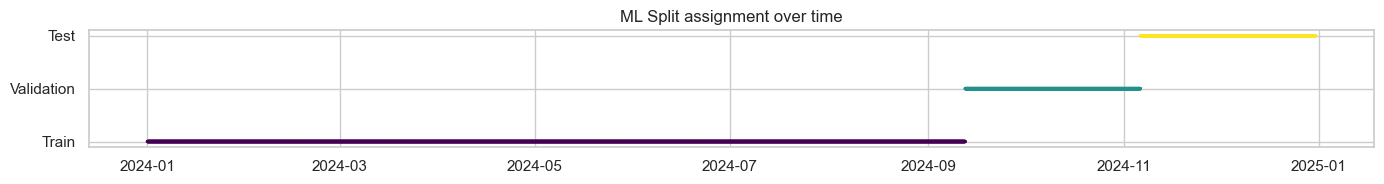

In [57]:
print(df["ML Split"].value_counts())

split_by_month = df.groupby("Month")["ML Split"].value_counts(normalize=True).unstack().round(2)
print("\nShare of each split by month:")
print(split_by_month)

plt.figure(figsize=(14, 2))
split_codes = df["ML Split"].map({"Train": 0, "Validation": 1, "Test": 2})
plt.scatter(df["Timestamp"], split_codes, c=split_codes, cmap="viridis", s=2)
plt.yticks([0, 1, 2], ["Train", "Validation", "Test"])
plt.title("ML Split assignment over time")
plt.tight_layout()
plt.show()

**Result:** the split is **chronological, not random** — Train covers January–August, Validation covers September–October, and Test covers late November–December. This means the eventual diffusion model's train/validation/test protocol should preserve this time-based ordering (never shuffle rows across it), since it's implicitly testing generalization to later months/different seasons rather than i.i.d. generalization.

### 2.9 Proposed conditioning variables per component

| Component | Target column | Proposed conditions | Rationale |
|---|---|---|---|
| IT – CPU | `P_CPU fleet (kW)` | `u_CPU fleet`, `hour_sin`/`hour_cos`, `IsWeekend` | Power is (near-exactly) linear in utilization; time-of-day/weekend flags capture the workload cycle utilization itself follows. |
| IT – GPU | `P_GPU fleet (kW)` | `u_GPU fleet`, `hour_sin`/`hour_cos`, `IsWeekend` | Same structure as CPU, different idle/peak curve. |
| Cooling | `P_cooling (kW)` | `P_IT total (kW)` (or `P_CPU fleet + P_GPU fleet`), `T_amb (°C)` / `CDH` | Cooling load is IT heat rejected at a temperature-dependent COP — both the heat source and ambient temperature are needed. |
| Losses | `P_loss total (kW)` | `P_IT total (kW)` | Losses are a near-fixed proportion (~16.5%) of IT load; no separate weather/time condition needed. |
| Fixed | `P_lighting + P_BMS/sec` | *(none — constant)* | Always 23 kW; not a meaningful diffusion modeling target on its own. |

This mirrors the earlier PV (net consumption + GHI) and heat-pump (HDH) examples: for each component we've picked the smallest set of physically-motivated variables that explain it, rather than throwing in every column.

### 2.10 Research roadmap / next steps

1. **Formalize the modeling problem**: define, per component, an input condition vector → output power mapping, using the table in 2.9 as the starting feature set.
2. **Respect the chronological split** found in 2.8 (Train: Jan–Aug, Validation: Sep–Oct, Test: Nov–Dec) for any model training/evaluation — do not shuffle across it.
3. **Address the determinism finding (2.7) before committing to diffusion**: since this dataset's components are near-deterministic given a few known variables, first fit simple baseline regressors (e.g. linear/GBM) per component as a sanity check. If a baseline regressor already reconstructs each component to within sensor-noise-level error, that's expected here — the diffusion model's benefit will only be visible when real residual uncertainty is present.
4. **Source noisier or complementary data** to make the generative-modeling angle meaningful: either (a) inject calibrated synthetic noise into this dataset to emulate real metering/behavioral uncertainty, (b) obtain the companion 2026 (warm-climate) file referenced in `Enterprise-data-description.md` for cross-climate generalization and finer IT sub-metering (memory/storage/NIC), or (c) apply the pipeline to real metered data once validated here.
5. **No PV/solar angle applies to this facility** (no on-site generation, no GHI column) — if a solar heat-gain effect on cooling load is later of interest, that would require sourcing external weather data (with a known facility location), not disaggregating existing columns.
6. **Add modeling dependencies** (e.g. `torch`, `diffusers`, a diffusion library, `scikit-learn` for baselines) once the condition sets above are locked in — intentionally left out of `requirements.txt` for this EDA-only pass.